In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
#import calmap
import calplot
import warnings
import string
import jieba
import pickle
import stopwordsiso
import datetime as dt
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF


sns.set(style='white')
warnings.simplefilter(action='ignore')
pd.set_option('display.max_columns', None)

In [ ]:
#df0 = pd.read_csv('2020/china_052020_tweets_csv_hashed.csv')
#df1 = pd.read_csv('2019/china_082019_1_tweets_csv_hashed.csv')
#df2 = pd.read_csv('2019/china_082019_2_tweets_csv_hashed.csv')
#df3 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part1.csv')
#df4 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part2.csv')
#df5 = pd.read_csv('2019/china_082019_3_tweets_csv_hashed_part3.csv')

#df_lst = [df0, df1, df2, df3, df4, df5]

In [ ]:
#def add_date(df):
#    df['tweet_date'] = df['tweet_time'].map(lambda x: str(x)[:-6])
#    df['tweet_date'] = pd.to_datetime(df['tweet_date'])

#for i in range(len(df_lst)):
#    add_date(df_lst[i])

In [ ]:
#def acc_creation_date(df):
#    df['account_creation_date'] = pd.to_datetime(df['account_creation_date'])

#for i in range(len(df_lst)):
#    acc_creation_date(df_lst[i])   

In [ ]:
#df = pd.concat([df0, df1, df2, df3, df4, df5])
#print("Combined dataframe shape:", df.shape)

In [ ]:
#df.to_pickle('my_df.pickle')

In [ ]:
#df19 = df[df['tweet_date'].dt.year == 2019]

In [ ]:
#df19.to_pickle('df19.pickle')

In [2]:
df19 = pd.read_pickle('df19.pickle')

In [3]:
len(df19)

1448625

In [4]:
def quick_look(df):
    
    print("Quick look at dataframe:")
    
    user_tweet_count = df['user_display_name'].value_counts()[0:10]
    print("Top 10 users:")
    for ind, val in user_tweet_count.iteritems():
        print("\t{:15s}{:7d}".format(ind, val) )
        
    print("\nTop 5 languages:")
    tweet_languages = df['tweet_language'].value_counts()[0:5]
    for ind, val in tweet_languages.iteritems():
        print("\t{:15s}{:7d}".format(ind, val))
    
    print('\n')

In [5]:
quick_look(df19)

Quick look at dataframe:
Top 10 users:
	cici qalya       46124
	小金鱼姬             42940
	amoy getol       39958
	ماهر الملالحة    38819
	follback?        19427
	ifb Mary         19160
	kosev            18765
	arpen            17666
	ursjennies       17422
	axel.            16357

Top 5 languages:
	zh              607909
	in              290205
	en              255054
	und             145940
	ar               48012




In [6]:
df19_zh = df19[df19['tweet_language'] == 'zh']
df19_en = df19[df19['tweet_language'] == 'en']

In [7]:
quick_look(df19_zh)
quick_look(df19_en)


Quick look at dataframe:
Top 10 users:
	萌萌豹              10194
	4面岂几歌             9852
	gwalcki4          9149
	Alleen            4402
	番茄不是西红柿           3912
	澎湖湾海燕             3885
	露水佳人              3881
	舞随风动              3616
	Dream News        3364
	西丽                3211

Top 5 languages:
	zh              607909


Quick look at dataframe:
Top 10 users:
	ifb Mary         19094
	anranhxy         10140
	DcLBrkAsE7xsA16IplWgY0EJiUZR+dvXdTvpkpoFTBA=  10107
	玉龍（Follow back💯）   7581
	大阪日下SDV 🍀         7577
	James albert      7464
	💕Escort-Ads.com   5699
	curry fan         5563
	许                 4443
	cici qalya        3898

Top 5 languages:
	en              255054




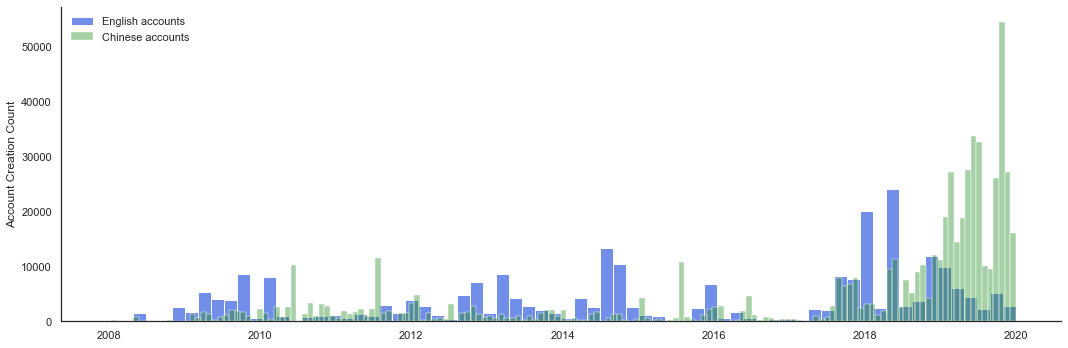

In [8]:
fig, ax = plt.subplots(figsize=(15,5))
#for a in [df_19_en.account_creation_date, df_19_zh.account_creation_date]:
#    sns.histplot(a, color = ['cadetblue','lightsalmon'])
#sns.histplot(df_19_en.account_creation_date, color='cadetblue')
#ax.grid(axis='x')
sns.histplot(df19_en.account_creation_date, color='royalblue', label='English accounts')
sns.histplot(df19_zh.account_creation_date, color='forestgreen', alpha=0.4, label='Chinese accounts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Account Creation Count')
plt.xlabel(None)
plt.legend(loc='upper left', frameon=False)

fig.tight_layout()

fig.show()


In [9]:
df19_zh[df19_zh['account_creation_date']==2019]

,tweetid,userid,user_display_name,user_screen_name,user_reported_location,user_profile_description,user_profile_url,follower_count,following_count,account_creation_date,account_language,tweet_language,tweet_text,tweet_time,tweet_client_name,in_reply_to_userid,in_reply_to_tweetid,quoted_tweet_tweetid,is_retweet,retweet_userid,retweet_tweetid,latitude,longitude,quote_count,reply_count,like_count,retweet_count,hashtags,urls,user_mentions,tweet_date,poll_choices


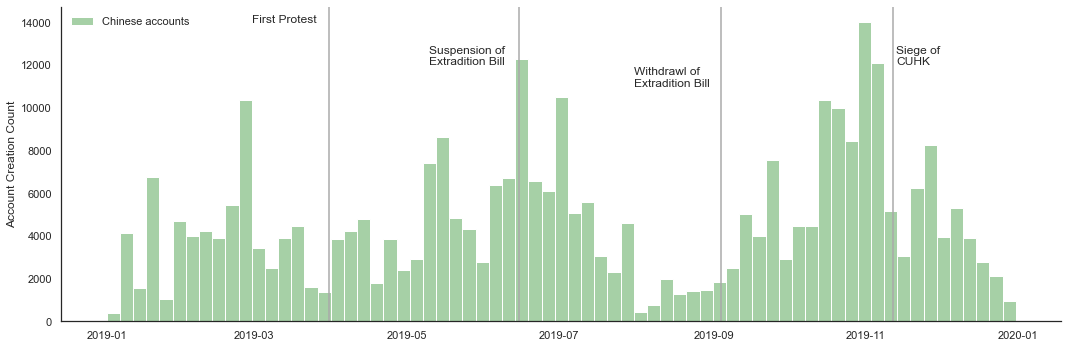

In [18]:
fig, ax = plt.subplots(figsize=(15,5))
#for a in [df_19_en.account_creation_date, df_19_zh.account_creation_date]:
#    sns.histplot(a, color = ['cadetblue','lightsalmon'])
#sns.histplot(df_19_en.account_creation_date, color='cadetblue')
#ax.grid(axis='x')
#sns.histplot(df19_en.account_creation_date, color='royalblue', label='English accounts')
sns.histplot(df19_zh[df19_zh['account_creation_date'].dt.year == 2019].account_creation_date, 
             color='forestgreen', alpha=0.4, label='Chinese accounts')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Account Creation Count')
plt.xlabel(None)
plt.legend(loc='upper left', frameon=False)


plt.axvline(dt.datetime(2019, 3, 31), color='darkgrey')
ax.annotate('First Protest', xy=(dt.datetime(2019, 2, 28), 14000))

plt.axvline(dt.datetime(2019, 6, 15), color='darkgrey')
ax.annotate('Suspension of\nExtradition Bill', xy=(dt.datetime(2019, 5, 10), 12000))

plt.axvline(dt.datetime(2019, 9, 4), color='darkgrey')
ax.annotate('Withdrawl of\nExtradition Bill', xy=(dt.datetime(2019, 7, 31), 11000))

plt.axvline(dt.datetime(2019, 11, 12), color='darkgrey')
ax.annotate('Siege of\nCUHK', xy=(dt.datetime(2019, 11, 13), 12000))



fig.tight_layout()

fig.show()


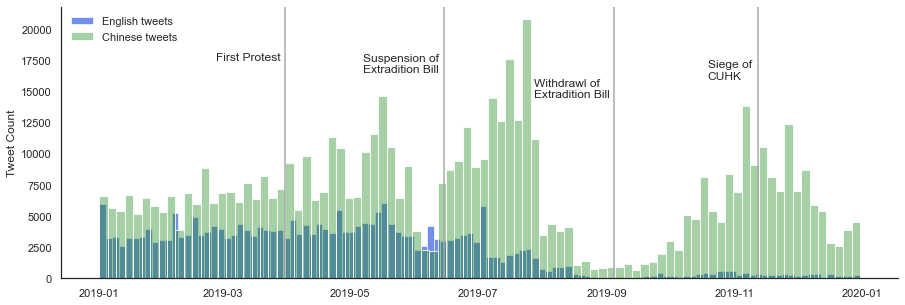

In [19]:
fig, ax = plt.subplots(figsize=(15,5))
sns.histplot(df19_en.tweet_date, color='royalblue', label='English tweets')
sns.histplot(df19_zh.tweet_date, color='forestgreen', alpha=0.4, label='Chinese tweets')
#plt.grid(b=None)
#ax.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylabel('Tweet Count')
plt.xlabel(None)
plt.legend(loc='upper left', frameon=False)

plt.axvline(dt.datetime(2019, 3, 31), color='darkgrey')
ax.annotate('First Protest', xy=(dt.datetime(2019, 2, 26), 17500))

plt.axvline(dt.datetime(2019, 6, 15), color='darkgrey')
ax.annotate('Suspension of\nExtradition Bill', xy=(dt.datetime(2019, 5, 7), 16500))

plt.axvline(dt.datetime(2019, 9, 4), color='darkgrey')
ax.annotate('Withdrawl of\nExtradition Bill', xy=(dt.datetime(2019, 7, 28), 14500))

plt.axvline(dt.datetime(2019, 11, 12), color='darkgrey')
ax.annotate('Siege of\nCUHK', xy=(dt.datetime(2019, 10, 19), 16000))

plt.show()

In [20]:
df19_zh_daily_count = df19_zh.groupby('tweet_date').size()

Text(0.1, 0.98, '2019 Daily Tweet Count')

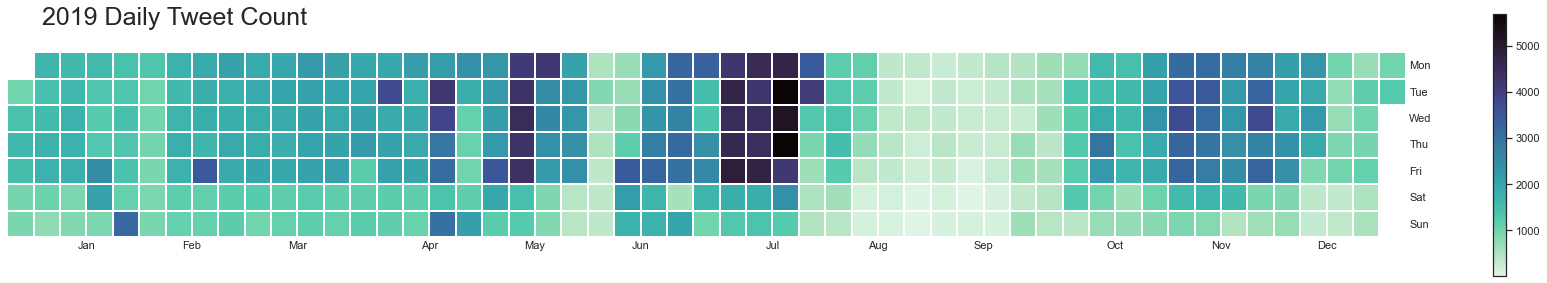

In [21]:
calplot.calplot(df19_zh_daily_count,  
                cmap='mako_r', 
                edgecolor=None,
                yearlabels = False,
                #yearlabel_kws={'fontsize':0},
                figsize=(25,4))
plt.suptitle('2019 Daily Tweet Count', fontsize=25, x=0.1)

In [74]:
df19_zh_text = pd.DataFrame(df19_zh['tweet_text'].copy())


print("No. of users tweeting in Chinese:", df19_zh['user_display_name'].nunique())
print("% of all users: {:0.2f}%".format(100 * df19_zh['user_display_name'].nunique() / df19['user_display_name'].nunique()))
print("No. of Chinese tweets:", len(df19_zh_text))
print("% of all tweets {:0.2f}%:".format(100 * len(df19_zh_text)/ len(df19)))

df19_zh_text.head(10)

No. of users tweeting in Chinese: 16391
% of all users: 95.63%
No. of Chinese tweets: 607909
% of all tweets 41.96%:


,tweet_text
0,郭瘟鬼这个大骗子，打着换汇的幌子通过他的地下钱庄骗钱，张口就来，每天就是在炫耀自己的骗术，殊...
5,欧冠-国米 第81分钟，埃斯波西托强行突入禁区右翼被胡梅尔斯铲倒，主裁判判罚了点球。但随...
7,只要你非常努力，总有一天你会发现，你永远无法拉近你跟有钱人的差距。生活会让你苦上一阵子，等你...
10,这样的天气适合趟在自己的被窝 https://t.co/Gz9x04ZLsS
11,明愛馬鞍山中學發現懷疑炸彈 兩生被捕 學校停課 支持警方深入調查！ #香港選舉 #愛港護港 ...
12,郭文贵和他的乌合之众已日薄西山，气息奄奄，你看他只剩下蹭热度、编谣言、耍嘴炮来苦苦支撑郭媒体...
15,.这个世界本就邋遢，所以没有什么可怕。每个人都有无法发泄的苦涩，都有无力排解的抑郁，而生活在...
21,無論係泛民派仲係建制派，止暴制亂恢復秩序之路任重而道遠，唔辜負選民嘅支持唔違反一國兩制嘅精神...
23,"骗子郭文贵不知疲倦地搞政治诽谤,讲述离奇故事，不过是一出又一出让人调侃的闹剧罢了。 http..."
24,不是某人使你烦恼，而是你拿某人的言行来烦恼自己。


In [75]:
df19_zhrt = df19_zh_text[df19_zh_text['tweet_text'].str.startswith('RT')]
print('% of retweet: {:02f}'.format(100 * len(df19_zhrt) / len(df19_zh_text)) )
df19_zhrt.head(20)

% of retweet: 41.395998


,tweet_text
42,RT @uVUK1tjTt1Psg2uVmojkk9EnzLCRQgFQ0ems1Vskjv...
73,RT @biwlX5qgW5IXi9VNnHIdP8PpMu+SCC8Ek0v8TeBaCK...
255,RT @anks8878: #游行 #暴徒 暴徒嘅言論自由係一種最惡毒嘅陰謀。如果言論可以殺...
365,RT @pKmziIiCxS9kLFy: #郭文贵 #班农 唯一能够算的上两人拥有的共同...
366,RT @eBOsBNcsVHp7of4xhOzYat4Mr6avxhMtln11PWQ9M=...
484,RT @CorkenEva: #班农 今天Axios爆班农与郭骗百万美元交易有图有真相，让郭...
527,RT @cv782Qn9cUEfex9UC8uvdSYbnGH3Cq5YROipbeFDQ=...
535,RT @NameIsTooShort: #暴徒废青 #逃犯条例 #香港游行 #香港暴徒 #撐...
606,RT @bp6r25rZWG+ir04bf+Ln97q1R9fwaBFPbL63XQY2eL...
645,RT @8aUjkXq77KRGElDVuPgnXFL1+yoyngS36XHoHsGk3c...


In [76]:
# crude cleaning to get an overall sense first
# We got rid of the retweets, which is major because they account for 41.4%.

print('Before clean:', len(df19_zh_text))

df19_zh_text['tweet_text'] = df19_zh_text['tweet_text'].str.replace(r'http\S+', '')
df19_zh_text['tweet_text'] = df19_zh_text['tweet_text'].str.replace(r'[\-_!“”@#$%&*+=\(\):;.·\\n】【—」「,/…👍 \|]', '')  
df19_zh_text = df19_zh_text[~df19_zh_text['tweet_text'].str.startswith('RT')]   # do not count RT

blanks = []

for i, tweet in df19_zh_text['tweet_text'].iteritems():  # iterate over the DataFrame
    if type(tweet)==str:            # avoid NaN values
        if tweet.isspace() or tweet == "":         # test 'review' for whitespace
            blanks.append(i)     # add matching index numbers to the list
            
print('Number of blanks:', len(blanks))

df19_zh_text.drop(blanks, inplace=True)

print('After clean:', len(df19_zh_text))

Before clean: 607909
Number of blanks: 0
After clean: 356230


In [45]:
newdf = df19_zh_text[df19_zh_text['tweet_text'].str.contains('】')]
newdf

,tweet_text


In [77]:
#chinese_stopwords = ['有', '没有', '會', '對', 'RT', ':', '\u3000', '.', '"', '!', ',','?','為', '佢', '喺', '唔', '」', '「', '哋', '係', '嘅',  '\xa0', '所谓', '一个', '\n', '=', '@', '+', '”', '“', '…', '#',  "、","。","〈","〉","《","》","一","一些","一何","一切","一则","一方面","一旦","一来","一样","一般","一转眼","七","万一","三","上","上下","下","不","不仅","不但","不光","不单","不只","不外乎","不如","不妨","不尽","不尽然","不得","不怕","不惟","不成","不拘","不料","不是","不比","不然","不特","不独","不管","不至于","不若","不论","不过","不问","与","与其","与其说","与否","与此同时","且","且不说","且说","两者","个","个别","中","临","为","为了","为什么","为何","为止","为此","为着","乃","乃至","乃至于","么","之","之一","之所以","之类","乌乎","乎","乘","九","也","也好","也罢","了","二","二来","于","于是","于是乎","云云","云尔","五","些","亦","人","人们","人家","什","什么","什么样","今","介于","仍","仍旧","从","从此","从而","他","他人","他们","他们们","以","以上","以为","以便","以免","以及","以故","以期","以来","以至","以至于","以致","们","任","任何","任凭","会","似的","但","但凡","但是","何","何以","何况","何处","何时","余外","作为","你","你们","使","使得","例如","依","依据","依照","便于","俺","俺们","倘","倘使","倘或","倘然","倘若","借","借傥然","假使","假如","假若","做","像","儿","先不先","光是","全体","全部","八","六","兮","共","关于","关于具体地说","其","其一","其中","其二","其他","其余","其它","其次","具体地说","具体说来","兼之","内","再","再其次","再则","再有","再者","再者说","再说","冒","冲","况且","几","几时","凡","凡是","凭","凭借","出于","出来","分","分别","则","则甚","别","别人","别处","别是","别的","别管","别说","到","前后","前此","前者","加之","加以","即","即令","即使","即便","即如","即或","即若","却","去","又","又及","及","及其","及至","反之","反而","反过来","反过来说","受到","另","另一方面","另外","另悉","只","只当","只怕","只是","只有","只消","只要","只限","叫","叮咚","可","可以","可是","可见","各","各个","各位","各种","各自","同","同时","后","后者","向","向使","向着","吓","吗","否则","吧","吧哒","含","吱","呀","呃","呕","呗","呜","呜呼","呢","呵","呵呵","呸","呼哧","咋","和","咚","咦","咧","咱","咱们","咳","哇","哈","哈哈","哉","哎","哎呀","哎哟","哗","哟","哦","哩","哪","哪个","哪些","哪儿","哪天","哪年","哪怕","哪样","哪边","哪里","哼","哼唷","唉","唯有","啊","啐","啥","啦","啪达","啷当","喂","喏","喔唷","喽","嗡","嗡嗡","嗬","嗯","嗳","嘎","嘎登","嘘","嘛","嘻","嘿","嘿嘿","四","因","因为","因了","因此","因着","因而","固然","在","在下","在于","地","基于","处在","多","多么","多少","大","大家","她","她们","好","如","如上","如上所述","如下","如何","如其","如同","如是","如果","如此","如若","始而","孰料","孰知","宁","宁可","宁愿","宁肯","它","它们","对","对于","对待","对方","对比","将","小","尔","尔后","尔尔","尚且","就","就是","就是了","就是说","就算","就要","尽","尽管","尽管如此","岂但","己","已","已矣","巴","巴巴","年","并","并且","庶乎","庶几","开外","开始","归","归齐","当","当地","当然","当着","彼","彼时","彼此","往","待","很","得","得了","怎","怎么","怎么办","怎么样","怎奈","怎样","总之","总的来看","总的来说","总的说来","总而言之","恰恰相反","您","惟其","慢说","我","我们","或","或则","或是","或曰","或者","截至","所","所以","所在","所幸","所有","才","才能","打","打从","把","抑或","拿","按","按照","换句话说","换言之","据","据此","接着","故","故此","故而","旁人","无","无宁","无论","既","既往","既是","既然","日","时","时候","是","是以","是的","更","曾","替","替代","最","月","有","有些","有关","有及","有时","有的","望","朝","朝着","本","本人","本地","本着","本身","来","来着","来自","来说","极了","果然","果真","某","某个","某些","某某","根据","欤","正值","正如","正巧","正是","此","此地","此处","此外","此时","此次","此间","毋宁","每","每当","比","比及","比如","比方","没奈何","沿","沿着","漫说","焉","然则","然后","然而","照","照着","犹且","犹自","甚且","甚么","甚或","甚而","甚至","甚至于","用","用来","由","由于","由是","由此","由此可见","的","的确","的话","直到","相对而言","省得","看","眨眼","着","着呢","矣","矣乎","矣哉","离","秒","竟而","第","等","等到","等等","简言之","管","类如","紧接着","纵","纵令","纵使","纵然","经","经过","结果","给","继之","继后","继而","综上所述","罢了","者","而","而且","而况","而后","而外","而已","而是","而言","能","能否","腾","自","自个儿","自从","自各儿","自后","自家","自己","自打","自身","至","至于","至今","至若","致","般的","若","若夫","若是","若果","若非","莫不然","莫如","莫若","虽","虽则","虽然","虽说","被","要","要不","要不是","要不然","要么","要是","譬喻","譬如","让","许多","论","设使","设或","设若","诚如","诚然","该","说","说来","请","诸","诸位","诸如","谁","谁人","谁料","谁知","贼死","赖以","赶","起","起见","趁","趁着","越是","距","跟","较","较之","边","过","还","还是","还有","还要","这","这一来","这个","这么","这么些","这么样","这么点儿","这些","这会儿","这儿","这就是说","这时","这样","这次","这般","这边","这里","进而","连","连同","逐步","通过","遵循","遵照","那","那个","那么","那么些","那么样","那些","那会儿","那儿","那时","那样","那般","那边","那里","都","鄙人","鉴于","针对","阿","除","除了","除外","除开","除此之外","除非","随","随后","随时","随着","难道说","零","非","非但","非徒","非特","非独","靠","顺","顺着","首先","︿","！","＃","＄","％","＆","（","）","＊","＋","，","０","１","２","３","４","５","６","７","８","９","：","；","＜","＞","？","＠","［","］","｛","｜","｝","～","￥"]


chinese_stopwords  = list(stopwordsiso.stopwords('zh'))
chinese_stopwords += [ '@', '_', '”', '“', ',', '#', ' ', '.', '-', '\n', '係',  '👍', '\u3000', '】', '【', 
                      '」', '「', '/', ':', '…', '來', '咪', '佢', '佢哋', '喺', '無', '嚟', '嘅', '對', '後', 
                      '與', '報', '哋', '唔', '系','没有' ]

def find_topics_words_zh(tweet_text, n_components, num_words):
    tfidf = TfidfVectorizer(max_df=0.9, min_df=5, tokenizer=jieba.cut, lowercase=False, stop_words=chinese_stopwords)
    dtm = tfidf.fit_transform(tweet_text['tweet_text'])


    nmf_model = NMF(n_components=n_components, random_state=2)
    nmf_model.fit(dtm)

  
    all_word_list = []
    
    for index, topic in enumerate(nmf_model.components_):
        print(f"The top {num_words} words for topic # {index + 1}")
        word_list = [tfidf.get_feature_names()[i] for i in topic.argsort()[-num_words:]]
        all_word_list.append(word_list)
        print(word_list)
        print("\n")
    
    return all_word_list    

In [78]:
all_word_list = find_topics_words_zh(df19_zh_text, 10, 10)

The top 10 words for topic # 1
['5', '3', '4', '已经', '世园', '时间', '现在', '北京', '报时', '整点']


The top 10 words for topic # 2
['社會', '會', '秩序', '守护', '和平', '稳定', '為', '法治', '暴力', '香港']


The top 10 words for topic # 3
['小蚂蚁', '直播', '表演', '蚂蚁', '基金', '班农', '已经', '谎言', '爆料', '郭文贵']


The top 10 words for topic # 4
['4', '5', '特朗普', '美', '贸易战', '发展', '经济', '国家', '美国', '中国']


The top 10 words for topic # 5
['一定', '警方', '港警', '行为', '暴力', '嚴懲', '法律', '必须', '严惩', '暴徒']


The top 10 words for topic # 6
['期', '标清', '吃', '自制', '欢乐', '官方', '卫视', '蚂蚁', '喜剧', 'YouTube']


The top 10 words for topic # 7
['直播', '爆料', '小蚂蚁', '谎言', '法治', '已经', '蚂蚁', '基金', '班农', '文贵']


The top 10 words for topic # 8
['加油', '警队', '執法', '警方', '香港政府', '执法', '香港', '港警', '警察', '支持']


The top 10 words for topic # 9
['谎言', '媒体', '挺', '已经', '真是', '骗', '蚂蚁', '老', '郭', '骗子']


The top 10 words for topic # 10
['走', '事', '世界', '努力', '知道', '爱', '想', '人生', '生活', '不要']




In [81]:
#font_path = 'MaShanZheng-Regular.ttf'
#font_path = 'SNsanafonGyou.ttf'
font_path = "NotoSansCJK-Regular.ttc"

def topic_to_wordcloud_zh(all_word_list, tweet_col):
#    for i in range(len(all_word_list)):
    word_list  = [word for sublist in all_word_list for word in sublist]
    count_list = []
    for word in word_list:
        count_list.append(tweet_col.str.count(word).sum())

    word_count_dict = dict(zip(word_list, count_list))

    wordcloud = WordCloud(font_path= font_path, width=1600, height=800, 
                        colormap = 'mako', 
                        background_color = 'white').generate_from_frequencies(word_count_dict)

    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.show()

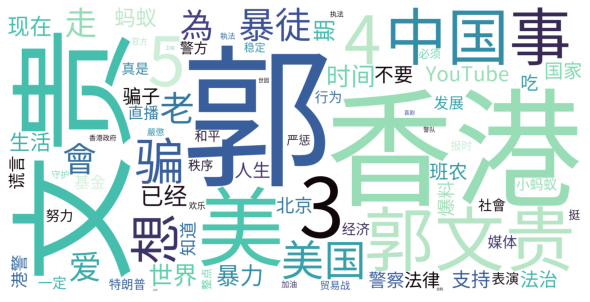

In [82]:
topic_to_wordcloud_zh(all_word_list, df19_zh_text['tweet_text'])

In [ ]:
萌萌豹 10194
	 4面岂几歌 9852
	 gwalcki4 9149
	 Alleen 4402
	 番茄不是西红柿 3912
	 澎湖湾海燕 3885
	 露水佳人 3881
	 舞随风动 3616
	 Dream News 3364
	 西丽 3211

In [83]:
df19_user3 = df19[df19['user_display_name'] == '萌萌豹']
df19_user3['tweet_text'].head(20)

209709    张雨绮喂朱正廷吃菜遭直接拒绝，正面暴击，扎心啊\n近期朱正廷和张雨绮一起参加了一档节目，结果...
209710    黑历史又遭起底!压垮宋慧乔的最后一根稻草?\n编者按：6月27日，宋慧乔与宋仲基宣布离婚，其...
209711    “not at all”风波令黄晓明抑郁：有过自杀想法\n 3月28日报道 近日，黄晓明在2...
209712    整容半年后 “太阳花女王”刘乔安变成这样\n “台湾(专题)包袱铺，吐槽没难度。”大家好，我...
209713    梁洛施请郑秀文等人家中小聚，李泽楷送的豪宅\n编者按：梁洛施的30年，可能就是很多豪门女孩子...
209715    史上最倒霉的歌手，写一首红一首，偏偏自己红\n编者按：前些年在小沈阳最火的时候，他的一首歌便...
209716    林志玲脸肿得发亮 网友：真没认出是她\n 我发现每一次只要是有大型的颁奖典礼，多多少少都会有...
209717    周立波妻子胡洁手撕唐爽：你不止身体有病 心更有病\n周立波妻子胡洁手撕唐爽：你不止身体有病 ...
209718    孟非晒与美女同游照片引热议，4字回应太直接了\n孟非是主持人，被网友们称为“中国月老”。主持...
209719    奶茶妹妹已成为过去式？只因她的到来让最美校\n编者按：说起“奶茶妹妹”，大概目前认识到她的人...
209720    那一年岳云鹏14岁，郭德纲26岁\n 20年前的1999年，像极了今天的2019年。 中国驻...
209721    孙俪片场被小孩追问认识邓超吗？她的回答真的\n编者按：孙俪娘娘的造型真是深入人心，前几天，在...
209722    妮可基德曼“替人手淫”入戏太深！老公崩溃\nHands down, the best wor...
209723    沉寂1年重磅回归 范冰冰下月跃登这里 自曝正在\n编者按：大陆女星范冰冰去（2018）年因逃...
209724    64岁周润发老当益壮 带方中信等好友雨中爬山\n 周润发带好友雨中爬山 网易娱乐6月1日报道...
209725    木村拓哉谈与窦靖童合作：我认识她妈妈啊\n日本(专题)流行天王木村拓哉和王菲(专题)女儿窦靖...
209726    新婚夫妇好甜蜜！郎朗悉尼开音乐会获娇妻陪伴\n近日，国际著名

In [84]:
df19_user1 = df19[df19['user_screen_name'] == 'HKpoliticalnew']
df19_user2 = df19[df19['user_screen_name'] == 'ctcc507']
print(len(df19_user1), len(df19_user2))

# both accounts tweeted significantly less than the actual top users (see above)

624 3584


In [85]:
df19_user1['tweet_text'].head(20)

1896013    RT @Tiffany52832078: @12fnXNOpp1j+gNAYnwAyskF+...
1896018    RT @HongKongFP: Around 6:40pm Friday, the LegC...
1896057    RT @Mrbangbboomm: @12fnXNOpp1j+gNAYnwAyskF+6Mo...
1896058    RT @Mrbangbboomm: @12fnXNOpp1j+gNAYnwAyskF+6Mo...
1896059    RT @RuthMiller916: @12fnXNOpp1j+gNAYnwAyskF+6M...
1896069    RT @nytchinese: 更新：\n• 示威者向守卫立法会的防暴警察投掷砖块、瓶子和雨...
1896070    RT @nytchinese: 《纽约时报》6月12日头版 https://t.co/Cg6...
1896079    RT @initiumnews: 【不只 #古裝劇，在中國，「樹大招風」的都難逃「管理」】全...
1896080    RT @initiumnews: 【香港媽媽們走上街頭：「告訴年輕人，他們不孤單。」】\n\...
1896081    RT @initiumnews: 【 #林鄭月娥 記者會全記錄：暫緩《 #逃犯條例》是特首決...
1896082    RT @initiumnews: 【2019金曲獎：#廖士賢 獲 #最佳台語專輯獎 】\n\...
1896083    RT @initiumnews: 【「 #港人眾籌」讓「 #反修例廣告」登上各國主流媒體，你...
1896097    RT @rthk_news: 郭榮鏗冀盡快修復以便10月復會可在大樓內開會 #本地 \nTh...
1896099    RT @rthk_news: 鄭若驊深夜離律政中心　示威者轉往其他地方示威後散去 #本地 \...
1896102    RT @rthk_news: 大批市民在愛丁堡廣場集會　促政府撤回條例及暴動定性 #本地 \...
1896104    RT @ctcc507: The legislative council belongs t...
1896108    RT @XTi8S43jO

In [87]:
print(len(df19_user1))

df19_user1 = df19_user1[~df19_user1['tweet_text'].str.startswith('RT')]
print("after removing retweets:", len(df19_user1))

df19_user1['tweet_text'].head(20)

515
after removing retweets: 515


1896875     @liuxiang_1987 呢些暴徒嘅理念就系「非暴力唔合作」，政府講東，我就往西，硬系要作對
1896876    @liamsanga Thank you for following me @12fnXNO...
1896877                                       @frances_WAN 😄
1896878    @deciiiuuu  Thanks for retweeting my tweet  #1...
1896879    @BBCWorld The police announced that 50,000 peo...
1896881               @ZhangGuodaoqilv 郭文贵谎话连篇，到处骗人，最终将收到审判！
1896882    @ChinaManjgdgi @Michaelwuguilin 很多大陸仔翻牆出嚟就系為了鬧...
1896886                                    @rourousibalaba 😄
1896889    @Alfred_Laimy Thanks for retweeting my tweet  ...
1896890                       @hylevel900 @BillyHui82 博攞同情啫啦
1896892    @PierryLynn 感謝你關注，但系作為香港人，我哋嘅市民仲系理性嘅，罪惡終究難逃制裁。...
1896893                              @gezhuxiong 大陸仔！講嘅唔錯！👍👍
1896895                         @Erwin09519408 You are right
1896896    @Kimen_J @BillyHui82 @BoscoLe39910882 手里冇寸鐵，但系...
1896900                             @urjscmpzslw 郭文贵的丧钟已然敲响！
1896902    @ahdee1004 @initiumnews OK，You can go to Faceb...
1896905                 

In [88]:
df19_user1['tweet_text'] = df19_user1['tweet_text'].str.replace(r'http\S+', '')
df19_user1['tweet_text'] = df19_user1['tweet_text'].str.replace(r'[A-Za-z@+#=_0-9,，.!]', '')

In [89]:
df19_user1['tweet_text'].head(20)

1896875                       呢些暴徒嘅理念就系「非暴力唔合作」政府講東我就往西硬系要作對
1896876                                                     
1896877                                                    😄
1896878                                               香港時政直擊
1896879                                                     
1896881                                  郭文贵谎话连篇到处骗人最终将收到审判！
1896882      很多大陸仔翻牆出嚟就系為了鬧中國嘲笑自己嘅國家有句話講嘅好「食人家嘅飯砸人家嘅鍋」講嘅就...
1896886                                                    😄
1896889                                               香港時政直擊
1896890                                               博攞同情啫啦
1896892     感謝你關注但系作為香港人我哋嘅市民仲系理性嘅罪惡終究難逃制裁。進入緊急狀態系對成個香港帶嚟...
1896893                                          大陸仔！講嘅唔錯！👍👍
1896895                                                     
1896896                                         手里冇寸鐵但系有磚頭😂😂
1896900                                          郭文贵的丧钟已然敲响！
1896902                                                     
1896905                 

In [90]:
blanks = []
for i, tweet in df19_user1['tweet_text'].iteritems():  # iterate over the DataFrame
    if type(tweet)==str:            # avoid NaN values
        if tweet.isspace() or tweet == "":         # test 'review' for whitespace
            blanks.append(i)     # add matching index numbers to the list
            
print('Number of blanks:', len(blanks))

df19_user1.drop(blanks, inplace=True)

Number of blanks: 34


In [91]:
print(len(df19_user1))
df19_user1['tweet_text'].head(20)

481


1896875                       呢些暴徒嘅理念就系「非暴力唔合作」政府講東我就往西硬系要作對
1896877                                                    😄
1896878                                               香港時政直擊
1896881                                  郭文贵谎话连篇到处骗人最终将收到审判！
1896882      很多大陸仔翻牆出嚟就系為了鬧中國嘲笑自己嘅國家有句話講嘅好「食人家嘅飯砸人家嘅鍋」講嘅就...
1896886                                                    😄
1896889                                               香港時政直擊
1896890                                               博攞同情啫啦
1896892     感謝你關注但系作為香港人我哋嘅市民仲系理性嘅罪惡終究難逃制裁。進入緊急狀態系對成個香港帶嚟...
1896893                                          大陸仔！講嘅唔錯！👍👍
1896896                                         手里冇寸鐵但系有磚頭😂😂
1896900                                          郭文贵的丧钟已然敲响！
1896905                                       嚴懲暴徒才能體現法律之威嚴！
1896916                                      你睇睇德國系點處置集會游行嘅 
1896927     呢些時間網上嘅「毒媒」大量信息與事實唔符合有意「拉偏架」抹黑警隊、抹黑特首最終目的唔難睇出...
1896932                        被網民發現了：所謂抗爭老母其實就系演員真實身份系工黨成員 
1896935      大陸人嘅質素參差唔齊有

In [93]:
all_word_list = find_topics_words_zh(df19_user1, 10, 10)

The top 10 words for topic # 1
['暫緩', '反對', '派', '政府', '反送', '修例', '遊行', '修訂', '條例', '逃犯']


The top 10 words for topic # 2
['他們', '咩', '時候', '一起', '輝', '梁家', '支持', '撐', '行動', '撐警']


The top 10 words for topic # 3
['游行', '法官', '聲', '政治', '市民', '感謝', '眾志', '英國', '為', '香港']


The top 10 words for topic # 4
['辛苦', '為', '嚴正', '總部', '社會', '警隊', '執法', '支持', '撐', '警察']


The top 10 words for topic # 5
['和平', '包圍', '即時', '夏', '防線', '現場', '總部', '警方', '道', '示威者']


The top 10 words for topic # 6
['請', '新聞', '關注', '指揮', '添華道', '反送', '現場', '香港', '時政', '直擊']


The top 10 words for topic # 7
['新', '台灣', '包圍', '想', '他們', '說', '要求', '河童', '之鋒', '黃']


The top 10 words for topic # 8
['洋犬', '華為', '啲', '外國', '港獨', '中國', '勢力', '美國', '顏色', '革命']


The top 10 words for topic # 9
['定性', '咁', '佔領', '暴亂', '鐵', '法律', '手無寸', '冇', '現場', '暴徒']


The top 10 words for topic # 10
['嚴重', '示威', '反', '派', '衝擊', '破壞', '會大樓', '暴力', '會', '立法']




In [94]:
df19_user2['tweet_text'].head(5)

658       #整点报时 现在北京时间： April 08, 2019 at 09:00AM
659       #整点报时 现在北京时间： April 17, 2019 at 05:01AM
3397    #整点报时 现在北京时间： January 06, 2019 at 04:00PM
3398    #整点报时 现在北京时间： January 17, 2019 at 09:00PM
3401      #整点报时 现在北京时间： April 22, 2019 at 08:00AM
Name: tweet_text, dtype: object

In [95]:
print(len(df19_user2))

#df19_user2 = df19_user2[~df19_user2['tweet_text'].str.startswith('#整点报时')]
df19_user2 = df19_user2[~df19_user2['tweet_text'].str.contains(r'[0-9][0-9]:[0-9][0-9][AP]M')]
print("after removing retweets:", len(df19_user2))

3584
after removing retweets: 553


In [96]:
df19_user2['tweet_text'].head(5)

3408    案情並不單純！甲龍化石為何總是呈現四腳朝天的離奇死狀？ https://t.co/mwiAg...
3409    Chinese, Indonesian Presidents Meet on Relatio...
3495    水行俠的亞特蘭提斯為何向陸地宣戰？看完電影也看真實的海洋危機 https://t.co/Ld...
3496         歐洲食品安全局│食安簡史5：新手培訓中心 https://t.co/csj5FgECv8
5624    從《我們與惡的距離》看無差別殺人(2)：普通的家庭為何會養出殺人犯？ https://t.c...
Name: tweet_text, dtype: object

In [97]:
print(len(df19_user2))

df19_user2 = df19_user2[~df19_user2['tweet_text'].str.contains('http')]
print("after removing retweets:", len(df19_user2))

553
after removing retweets: 39


In [98]:
df19_user2['tweet_text'].head(40)

48744                        @ingaibragimova1 郭WG的日子越来越不好过了！
91241                                      @3Sy003 郭文贵已走投无路了
195299     @SuiBianXiaoGe 或许一觉醒来，或许明天，或许不久的将来，香港人就会明白不论是运...
278180     The second Wanshou Dialogue on Global Security...
278803     文贵的爆料，语言污秽粗俗，内容异想天开，编造故事一个接一个，没有一丝道德感，羞耻感。小蚂蚁们...
300809        @redwallpusher 郭文贵说谎只图一时之快，结果就是得不到真正的幸福，只能得到悲哀
301012     @redwallpusher 文贵整天编造一些虚假的事件，谎话连篇，自以为能蒙蔽全天下人。殊...
306928     An exhibition marking the 70th anniversary of ...
357345     The legislative council belongs to the people ...
469292     Chinese researchers have developed a high-ener...
469293     昨日，加拿大交通部长马克·加尔表示加拿大不会停飞波音737-8机型。报道称马克·加尔诺在当地...
534903     Engineers at NASA's Jet Propulsion Laboratory ...
625311     June 17th The 53rd Paris International Aerospa...
642849     RT @AngelMart52: 郭文贵说谎的本领看来一直在自己的血液中流淌着，随时随地、随...
703118     RT @zhanfan2: 瘟龟重出江湖，但估计依旧是老生常谈，内容空洞无感，毫无证据实质性...
703549     RT @zhanfan2: 郭骗的真实面目，最终都会被揭露，但惊醒的人们会越来越多，所以奉劝...
768152     RT @75ZbndCbt

In [ ]:
stop_words_en = stopwords.words('english')
stop_words_en += list(string.punctuation)
stop_words_en += ['rt', '’', '\'s', '``', '\'\'', '““', 'n\'t', 'amp', 'u' , '']
lemmatizer = WordNetLemmatizer()

def find_topics_words_en(tweet_col, n_components, num_words):
    tfidf = TfidfVectorizer(max_df=0.8, min_df=5, stop_words=stop_words_en)
    dtm = tfidf.fit_transform(tweet_col)


    nmf_model = NMF(n_components=n_components, random_state=2)
    nmf_model.fit(dtm)
    
  
    all_word_list = []
    
    for index, topic in enumerate(nmf_model.components_):
        print(f"The top {num_words} words for topic # {index + 1}")
        word_list = [tfidf.get_feature_names()[i] for i in topic.argsort()[-num_words:]]
        all_word_list.append(word_list)
        print(word_list)
        print("\n")
    
    return all_word_list


